In [1]:
from datetime import datetime

import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from src.config import MPL_STYLE_DIR
from src.db import PBWarehouse
from src.models import Tweet

warehouse = PBWarehouse()

plt.style.use(MPL_STYLE_DIR / "iragca_ml.mplstyle")

2025-07-06 10:40:34.861 | INFO     | src.config:<module>:25 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-07-06 10:40:34.862 | INFO     | src.config:<module>:59 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-07-06 10:40:34.862 | INFO     | src.config:<module>:60 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


In [2]:
data = warehouse.client.collection("tweets_v2").get_full_list(query_params={"filter": "has_blm_hashtag = true || is_reply_to_blm = true"})
tweets: list[Tweet] = [Tweet(**r.__dict__) for r in data]

In [3]:
df = (
    pl.DataFrame(
    [t.model_dump() for t in tweets],
    schema={
        "tweet_id": pl.Utf8,
        "text": pl.Utf8,
        "status_link": pl.Utf8,
        "user_id": pl.Utf8,
        "extremist": pl.Boolean,
        "is_annotated": pl.Boolean,
        "bookmark_count": pl.Int64,
        "views": pl.Int64,
        "retweet_count": pl.Int64,
        "favorite_count": pl.Int64,
        "reply_count": pl.Int64,
        "quote_count": pl.Int64,
        "in_reply_to_status_id": pl.Utf8,
        "conversation_id": pl.Utf8,
        "retweet_tweet_id": pl.Utf8,
        "quoted_status_id": pl.Utf8,
        "community_note": pl.Utf8,
        "language": pl.Utf8,
        "source": pl.Utf8,
        "creation_date": pl.Utf8,
        "has_blm_hashtag": pl.Boolean,
        "fetched_replies": pl.Boolean,
        "is_reply_to_blm": pl.Boolean,
    })
    .with_columns(
    pl.col("creation_date").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.3fZ")  
    )
)
df

tweet_id,text,status_link,user_id,extremist,is_annotated,bookmark_count,views,retweet_count,favorite_count,reply_count,quote_count,in_reply_to_status_id,conversation_id,retweet_tweet_id,quoted_status_id,community_note,language,source,creation_date,has_blm_hashtag,fetched_replies,is_reply_to_blm
str,str,str,str,bool,bool,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,datetime[ms],bool,bool,bool
"""1286447415080312833""","""Heyhey if you are someone/know…","""https://x.com/ChuckMockler/sta…","""347913343""",null,false,0,0,1,2,0,0,"""""","""1286447415080312833""","""""","""""","""""","""en""","""Twitter for iPhone""",2020-07-23 23:45:39,true,true,false
"""1286440938106163203""","""Thank you @VoteAdamMedrano for…","""https://x.com/AdamBazaldua/sta…","""833871911272722433""",null,false,0,0,4,16,4,1,"""""","""1286440938106163203""","""""","""""","""""","""en""","""Twitter for iPhone""",2020-07-23 23:19:55,true,true,false
"""1286450496329285632""","""I have ten-ish years of experi…","""https://x.com/LilyShumarKray/s…","""773036078""",null,false,0,0,0,3,0,0,"""1286450494349533184""","""1286450494349533184""","""""","""""","""""","""en""","""""",2020-07-23 23:57:54,false,true,true
"""1286449764507291650""","""Opening day is underway for @m…","""https://x.com/HarrisWarRoom/st…","""1148212967332204544""",null,false,0,0,10,50,0,1,"""""","""1286449764507291650""","""""","""""","""""","""en""","""Twitter Web App""",2020-07-23 23:54:59,true,true,false
"""1286439076233650177""","""People are either being Dof an…","""https://x.com/SoliPhilander/st…","""108571906""",null,false,0,0,0,7,0,0,"""""","""1286439076233650177""","""""","""""","""""","""en""","""Twitter for Android""",2020-07-23 23:12:31,true,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1465372890409357320""","""https://t.co/EjuTsw1fb6""","""https://x.com/lostforwordsjay/…","""1346949465928822787""",null,false,0,0,0,0,1,0,"""1465372810323402753""","""1465372810323402753""","""""","""""","""""","""zxx""","""""",2021-11-29 17:31:37,false,false,true
"""1641966116078485504""","""@lancewallnau I have wondered …","""https://x.com/JohnnaHouseman/s…","""1591994199246766080""",null,false,0,8,0,0,0,0,"""1641457896692097024""","""1641457896692097024""","""""","""""","""""","""en""","""""",2023-04-01 00:50:02,false,false,true
"""1393686849483427849""","""@DMVBlackLives https://t.co/Vw…","""https://x.com/EEhGeXFEkoMrg5l/…","""1229358368084709377""",null,false,1,0,1,4,0,0,"""1393676308203323392""","""1393676308203323392""","""""","""""","""""","""qme""","""""",2021-05-15 21:56:53,false,false,true


In [4]:
sorted_df = df.sort(pl.col("creation_date")).group_by_dynamic("creation_date", every="1mo").agg(
    [
        pl.col("tweet_id").count().alias("total_tweets"),
    ])

Text(0.5, 1.0, 'Total Tweets per Month')

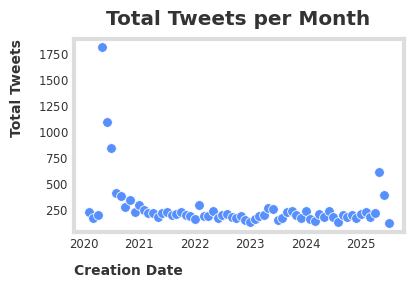

In [5]:
sns.scatterplot(
    data=sorted_df.to_pandas(),
    x="creation_date",
    y="total_tweets",
    marker="o")

plt.xlabel("Creation Date")
plt.ylabel("Total Tweets")
plt.title("Total Tweets per Month")